# EDA 06 - Revenue Weekday Effect

This notebook analyzes revenue by day of week using `sales.csv`, with a focus on weekday/weekend effects, stability over time, distribution patterns, and weekday-based forecast features.

## 1. Setup and file discovery

Locate `sales.csv` recursively from the current working directory and configure common analysis settings. No EDA outputs are saved to separate files.

In [1]:
import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 160)

PROJECT_ROOT = Path(os.getcwd())
SALES_FILENAME = "sales.csv"
WEEKDAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
WEEKDAY_ABBR = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

analysis_ready = False
warning_messages = []
daily = pd.DataFrame()
weekday_stats = pd.DataFrame()
weekend_comparison_df = pd.DataFrame()
year_weekday_avg = pd.DataFrame()
year_pattern_df = pd.DataFrame()
volatility_df = pd.DataFrame()
outlier_days = pd.DataFrame()
feature_preview = pd.DataFrame()

best_weekday = None
weakest_weekday = None
weekend_statement = "Not evaluated."
stability_statement = "Not evaluated."
high_volatility_weekdays = []
recommended_features = ["dayofweek", "weekday_name", "is_weekend", "weekday_sin", "weekday_cos"]


def money_formatter(value, _position=None):
    if pd.isna(value):
        return ""
    abs_value = abs(value)
    if abs_value >= 1_000_000_000:
        return f"{value / 1_000_000_000:,.1f}B"
    if abs_value >= 1_000_000:
        return f"{value / 1_000_000:,.1f}M"
    if abs_value >= 1_000:
        return f"{value / 1_000:,.0f}K"
    return f"{value:,.0f}"


currency_axis = FuncFormatter(money_formatter)

sales_matches = sorted(PROJECT_ROOT.rglob(SALES_FILENAME), key=lambda p: (len(p.parts), str(p).lower()))
sales_path = sales_matches[0] if sales_matches else None

file_discovery_df = pd.DataFrame([{
    "file": SALES_FILENAME,
    "found": sales_path is not None,
    "path": str(sales_path.relative_to(PROJECT_ROOT)) if sales_path else None,
    "match_count": len(sales_matches),
}])

if sales_path is None:
    warning_messages.append("sales.csv was not found under the current working directory.")

print(f"Project root: {PROJECT_ROOT}")
display(file_discovery_df)
if len(sales_matches) > 1:
    display(pd.DataFrame({"matched_paths": [str(p.relative_to(PROJECT_ROOT)) for p in sales_matches]}))

Project root: D:\Code\Datathon 2026


,file,found,path,match_count
0,sales.csv,True,datathon-2026-round-1\sales.csv,1


## 2. Load sales data

Load the sales file safely with pandas. If loading fails, later sections display warnings instead of crashing.

In [2]:
sales_raw = None
load_error = None

if sales_path is None:
    load_error = "sales.csv was not found."
else:
    try:
        sales_raw = pd.read_csv(sales_path, low_memory=False)
    except Exception as exc:
        load_error = repr(exc)
        warning_messages.append(f"Could not load sales.csv: {load_error}")

if sales_raw is None:
    load_summary_df = pd.DataFrame([{
        "file": SALES_FILENAME,
        "loaded": False,
        "rows": np.nan,
        "columns": np.nan,
        "error": load_error,
    }])
else:
    load_summary_df = pd.DataFrame([{
        "file": SALES_FILENAME,
        "loaded": True,
        "rows": len(sales_raw),
        "columns": len(sales_raw.columns),
        "error": "",
    }])

display(load_summary_df)
if sales_raw is not None:
    display(sales_raw.head())

,file,loaded,rows,columns,error
0,sales.csv,True,3833,3,


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


## 3. Identify date and revenue columns

Detect the most likely date and revenue columns using normalized column names, date parse success, numeric parse success, and revenue-related naming hints. If a direct revenue column is not present, numeric columns are scored as potential revenue proxies.

In [3]:
def normalize_name(name):
    return re.sub(r"[^a-z0-9]+", "_", str(name).strip().lower()).strip("_")


def non_empty_mask(series):
    if pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series):
        return series.astype("string").str.strip().ne("") & series.notna()
    return series.notna()


def numeric_series(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    cleaned = (
        series.astype("string")
        .str.strip()
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace(r"^\((.*)\)$", r"-\1", regex=True)
    )
    return pd.to_numeric(cleaned, errors="coerce")


def parse_datetime_series(series):
    if pd.api.types.is_datetime64_any_dtype(series):
        return pd.to_datetime(series, errors="coerce")
    return pd.to_datetime(series, errors="coerce")


def date_score(column_name, series):
    name = normalize_name(column_name)
    name_tokens = set(name.split("_"))
    exact_date_names = {"date", "ds", "day", "sales_date", "order_date", "transaction_date", "created_at", "timestamp"}
    date_terms = {"date", "day", "time", "timestamp", "datetime"}

    name_points = 0
    if name in exact_date_names:
        name_points += 5
    elif name_tokens & date_terms or any(term in name for term in ["date", "timestamp", "datetime"]):
        name_points += 3

    if pd.api.types.is_numeric_dtype(series) and name_points == 0:
        return {
            "column": column_name,
            "normalized_name": name,
            "date_score": -5.0,
            "date_parse_success": 0.0,
            "plausible_date_share": 0.0,
            "non_empty_values": int(non_empty_mask(series).sum()),
        }

    parsed = parse_datetime_series(series)
    mask = non_empty_mask(series)
    non_empty = int(mask.sum())
    parsed_valid = parsed[mask].notna() if non_empty else pd.Series(dtype=bool)
    parse_success = float(parsed_valid.mean()) if non_empty else 0.0

    parsed_non_null = parsed[mask].dropna()
    if len(parsed_non_null):
        plausible = parsed_non_null.between(pd.Timestamp("1990-01-01"), pd.Timestamp("2100-12-31"))
        plausible_share = float(plausible.mean())
        unique_dates = int(parsed_non_null.dt.normalize().nunique())
    else:
        plausible_share = 0.0
        unique_dates = 0

    score = name_points + (3 * parse_success) + (2 * plausible_share) + min(unique_dates / 20, 1)
    return {
        "column": column_name,
        "normalized_name": name,
        "date_score": round(score, 4),
        "date_parse_success": round(parse_success, 4),
        "plausible_date_share": round(plausible_share, 4),
        "non_empty_values": non_empty,
    }


def revenue_score(column_name, series):
    name = normalize_name(column_name)
    name_tokens = set(name.split("_"))
    positive_terms = {
        "revenue": 7,
        "sales": 5,
        "sale": 4,
        "amount": 4,
        "total": 3,
        "value": 2,
        "gmv": 5,
        "turnover": 5,
        "net": 2,
        "gross": 2,
    }
    negative_terms = {
        "id": 6,
        "key": 5,
        "code": 4,
        "date": 6,
        "time": 5,
        "year": 4,
        "month": 4,
        "day": 4,
        "qty": 5,
        "quantity": 5,
        "count": 4,
        "cost": 4,
        "cogs": 5,
        "price": 2,
        "rate": 3,
        "percent": 4,
        "percentage": 4,
    }

    name_points = 0
    for term, points in positive_terms.items():
        if term in name_tokens or term in name:
            name_points += points

    penalty = 0
    for term, points in negative_terms.items():
        if term in name_tokens or term in name:
            penalty += points

    numeric = numeric_series(series)
    mask = non_empty_mask(series)
    non_empty = int(mask.sum())
    numeric_non_null = int(numeric[mask].notna().sum()) if non_empty else 0
    numeric_success = numeric_non_null / non_empty if non_empty else 0.0
    numeric_valid = numeric[mask].dropna()

    if len(numeric_valid):
        positive_share = float((numeric_valid > 0).mean())
        nonzero_share = float((numeric_valid != 0).mean())
        mean_value = float(numeric_valid.mean())
        std_value = float(numeric_valid.std(ddof=1)) if len(numeric_valid) > 1 else 0.0
        abs_median = float(numeric_valid.abs().median())
    else:
        positive_share = 0.0
        nonzero_share = 0.0
        mean_value = np.nan
        std_value = np.nan
        abs_median = 0.0

    variability_points = 1.0 if pd.notna(std_value) and std_value > 0 else 0.0
    magnitude_points = min(np.log10(abs_median + 1) / 4, 1.5) if abs_median > 0 else 0.0
    score = name_points - penalty + (3 * numeric_success) + positive_share + nonzero_share + variability_points + magnitude_points

    return {
        "column": column_name,
        "normalized_name": name,
        "revenue_score": round(float(score), 4),
        "numeric_parse_success": round(float(numeric_success), 4),
        "positive_share": round(float(positive_share), 4),
        "non_empty_values": non_empty,
        "numeric_values": numeric_non_null,
        "mean_numeric_value": mean_value,
        "std_numeric_value": std_value,
        "has_revenue_name_hint": any(term in name for term in ["revenue", "sales", "amount", "gmv", "turnover"]),
    }


if sales_raw is None or sales_raw.empty:
    date_col = None
    revenue_col = None
    parsed_date = None
    parsed_revenue = None
    date_candidates_df = pd.DataFrame()
    revenue_candidates_df = pd.DataFrame()
    column_detection_df = pd.DataFrame([{"warning": "sales.csv was not loaded or is empty."}])
    warning_messages.append("Column detection skipped because sales.csv was not loaded or is empty.")
else:
    date_candidates_df = pd.DataFrame([date_score(col, sales_raw[col]) for col in sales_raw.columns])
    revenue_candidates_df = pd.DataFrame([revenue_score(col, sales_raw[col]) for col in sales_raw.columns])

    date_candidates_df = date_candidates_df.sort_values(["date_score", "date_parse_success", "plausible_date_share"], ascending=False)
    revenue_candidates_df = revenue_candidates_df.sort_values(["revenue_score", "numeric_parse_success", "positive_share"], ascending=False)

    selected_date = date_candidates_df.iloc[0] if len(date_candidates_df) else None
    selected_revenue = revenue_candidates_df.iloc[0] if len(revenue_candidates_df) else None

    date_col = None
    revenue_col = None
    if selected_date is not None and selected_date["date_parse_success"] >= 0.50 and selected_date["plausible_date_share"] >= 0.50:
        date_col = selected_date["column"]

    if selected_revenue is not None and selected_revenue["numeric_parse_success"] >= 0.75 and selected_revenue["revenue_score"] >= 2.0:
        revenue_col = selected_revenue["column"]

    parsed_date = parse_datetime_series(sales_raw[date_col]) if date_col else None
    parsed_revenue = numeric_series(sales_raw[revenue_col]) if revenue_col else None

    if date_col is None:
        warning_messages.append("No usable date column was found. Weekday EDA cannot be completed.")
    if revenue_col is None:
        warning_messages.append("No usable revenue or revenue-like numeric column was found. Revenue weekday EDA cannot be completed.")
    elif not bool(selected_revenue["has_revenue_name_hint"]):
        warning_messages.append(f"Revenue column was inferred from numeric data rather than a direct revenue name: {revenue_col}.")

    column_detection_df = pd.DataFrame([{
        "selected_date_column": date_col,
        "selected_revenue_column": revenue_col,
        "date_parse_success": float(parsed_date.notna().mean()) if parsed_date is not None else np.nan,
        "revenue_numeric_success": float(parsed_revenue.notna().mean()) if parsed_revenue is not None else np.nan,
        "revenue_inferred_without_name_hint": bool(revenue_col and not bool(selected_revenue["has_revenue_name_hint"])),
    }])

print("Selected columns")
display(column_detection_df)
if len(date_candidates_df):
    print("Date candidates")
    display(date_candidates_df)
if len(revenue_candidates_df):
    print("Revenue candidates")
    display(revenue_candidates_df)

Selected columns


,selected_date_column,selected_revenue_column,date_parse_success,revenue_numeric_success,revenue_inferred_without_name_hint
0,Date,Revenue,1.0,1.0,False


Date candidates


,column,normalized_name,date_score,date_parse_success,plausible_date_share,non_empty_values
0,Date,date,11.0,1.0,1.0,3833
1,Revenue,revenue,-5.0,0.0,0.0,3833
2,COGS,cogs,-5.0,0.0,0.0,3833


Revenue candidates


,column,normalized_name,revenue_score,numeric_parse_success,positive_share,non_empty_values,numeric_values,mean_numeric_value,std_numeric_value,has_revenue_name_hint
1,Revenue,revenue,14.5,1.0,1.0,3833,3833,4.286584e+06,2.624840e+06,True
2,COGS,cogs,2.5,1.0,1.0,3833,3833,3.695134e+06,2.219789e+06,False
0,Date,date,-6.0,0.0,0.0,3833,0,NaN,NaN,False


## 4. Prepare daily revenue and weekday fields

Parse dates and revenue, aggregate multiple rows per day by summing revenue, and create weekday fields for EDA and forecasting. Missing calendar dates are reported and left unfilled because absent records are not automatically zero revenue.

In [4]:
if sales_raw is None or date_col is None or revenue_col is None:
    analysis_ready = False
    prep_summary_df = pd.DataFrame([{"ready": False, "warning": "Missing loaded data, date column, or revenue column."}])
    display(prep_summary_df)
else:
    work = pd.DataFrame({
        "date_raw": sales_raw[date_col],
        "revenue_raw": sales_raw[revenue_col],
        "date": parsed_date,
        "revenue": parsed_revenue,
    })
    work["date"] = pd.to_datetime(work["date"], errors="coerce").dt.normalize()

    initial_rows = len(work)
    invalid_date_rows = int(work["date"].isna().sum())
    invalid_revenue_rows = int(work["revenue"].isna().sum())
    work = work.dropna(subset=["date", "revenue"]).copy()

    if work.empty:
        analysis_ready = False
        warning_messages.append("No rows remained after dropping invalid dates or revenue values.")
        prep_summary_df = pd.DataFrame([{
            "ready": False,
            "initial_rows": initial_rows,
            "invalid_date_rows": invalid_date_rows,
            "invalid_revenue_rows": invalid_revenue_rows,
            "usable_rows": 0,
        }])
        display(prep_summary_df)
    else:
        duplicate_date_rows = int(work.duplicated("date", keep=False).sum())
        daily = (
            work.groupby("date", as_index=False)
            .agg(revenue=("revenue", "sum"), source_rows=("revenue", "size"))
            .sort_values("date")
            .reset_index(drop=True)
        )

        full_calendar = pd.date_range(daily["date"].min(), daily["date"].max(), freq="D")
        observed_dates = pd.DatetimeIndex(daily["date"])
        missing_dates = full_calendar.difference(observed_dates)
        inferred_frequency = pd.infer_freq(observed_dates) if len(observed_dates) >= 3 else None
        median_gap_days = float(daily["date"].diff().dt.days.dropna().median()) if len(daily) > 1 else np.nan

        daily["dayofweek"] = daily["date"].dt.dayofweek
        daily["weekday_name"] = pd.Categorical(daily["date"].dt.day_name(), categories=WEEKDAY_ORDER, ordered=True)
        daily["is_weekend"] = daily["dayofweek"].isin([5, 6])
        daily["weekday_sin"] = np.sin(2 * np.pi * daily["dayofweek"] / 7)
        daily["weekday_cos"] = np.cos(2 * np.pi * daily["dayofweek"] / 7)
        daily["year"] = daily["date"].dt.year
        daily["day_type"] = np.where(daily["is_weekend"], "Weekend", "Weekday")

        analysis_ready = True
        if duplicate_date_rows:
            warning_messages.append(f"Found {duplicate_date_rows:,} source rows on dates with duplicates; revenue was aggregated by date using sum.")
        if len(missing_dates):
            warning_messages.append(f"Found {len(missing_dates):,} missing calendar dates between the first and last observed sales dates; weekday analysis uses observed dates only.")
        if pd.notna(median_gap_days) and median_gap_days > 1:
            warning_messages.append(f"Observed dates are not contiguous daily records; median gap is {median_gap_days:.1f} days.")

        prep_summary_df = pd.DataFrame([{
            "ready": True,
            "initial_rows": initial_rows,
            "invalid_date_rows": invalid_date_rows,
            "invalid_revenue_rows": invalid_revenue_rows,
            "usable_source_rows": len(work),
            "daily_rows_after_aggregation": len(daily),
            "duplicate_date_source_rows": duplicate_date_rows,
            "first_date": daily["date"].min().date(),
            "last_date": daily["date"].max().date(),
            "expected_calendar_days": len(full_calendar),
            "missing_calendar_days": len(missing_dates),
            "inferred_observed_frequency": inferred_frequency,
            "median_gap_days": median_gap_days,
        }])
        display(prep_summary_df)
        display(daily.head(10))

,ready,initial_rows,invalid_date_rows,invalid_revenue_rows,usable_source_rows,daily_rows_after_aggregation,duplicate_date_source_rows,first_date,last_date,expected_calendar_days,missing_calendar_days,inferred_observed_frequency,median_gap_days
0,True,3833,0,0,3833,3833,0,2012-07-04,2022-12-31,3833,0,D,1.0


,date,revenue,source_rows,dayofweek,weekday_name,is_weekend,weekday_sin,weekday_cos,year,day_type
0,2012-07-04,5123547.94,1,2,Wednesday,False,0.974928,-0.222521,2012,Weekday
1,2012-07-05,2751773.45,1,3,Thursday,False,0.433884,-0.900969,2012,Weekday
2,2012-07-06,3054029.42,1,4,Friday,False,-0.433884,-0.900969,2012,Weekday
3,2012-07-07,2667930.94,1,5,Saturday,True,-0.974928,-0.222521,2012,Weekend
4,2012-07-08,2360851.90,1,6,Sunday,True,-0.781831,0.623490,2012,Weekend
5,2012-07-09,3548386.46,1,0,Monday,False,0.000000,1.000000,2012,Weekday
6,2012-07-10,5234938.62,1,1,Tuesday,False,0.781831,0.623490,2012,Weekday
7,2012-07-11,5582884.78,1,2,Wednesday,False,0.974928,-0.222521,2012,Weekday
8,2012-07-12,5734632.02,1,3,Thursday,False,0.433884,-0.900969,2012,Weekday
9,2012-07-13,5309511.71,1,4,Friday,False,-0.433884,-0.900969,2012,Weekday


## 5. Revenue by day of week

Calculate total, average, median, spread, min, max, and day counts for each weekday. Weekdays are ranked by average daily revenue.

,weekday,total_revenue,average_daily_revenue,median_daily_revenue,std_daily_revenue,min_daily_revenue,max_daily_revenue,number_of_days,rank_by_average_revenue
0,Monday,2.358136e+09,4.311035e+06,3848593.440,2.339844e+06,545563.72,15902645.06,547,4.0
1,Tuesday,2.442411e+09,4.465103e+06,3925730.260,2.606768e+06,679248.37,17347427.27,547,3.0
2,Wednesday,2.564676e+09,4.680065e+06,3929024.180,3.007995e+06,370653.23,20905271.35,548,1.0
3,Thursday,2.478628e+09,4.523044e+06,3629496.985,2.971430e+06,306693.87,19289944.12,548,2.0
4,Friday,2.217422e+09,4.046390e+06,3359439.985,2.589911e+06,586748.17,19245165.78,548,6.0
5,Saturday,2.140806e+09,3.906581e+06,3384605.360,2.407521e+06,279813.94,17529108.34,548,7.0
6,Sunday,2.228398e+09,4.073854e+06,3603536.480,2.270571e+06,574193.42,15158669.18,547,5.0


Best-selling weekday by average revenue: Wednesday
Weakest weekday by average revenue: Saturday


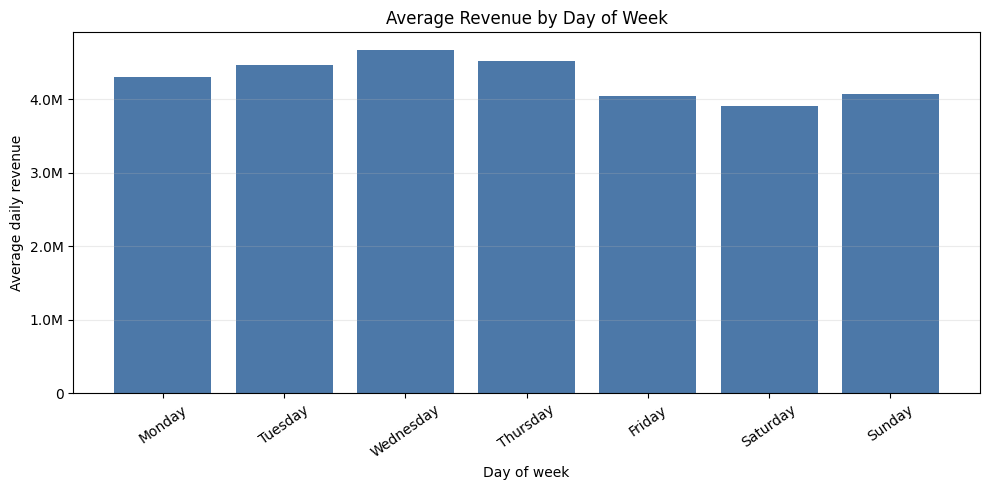

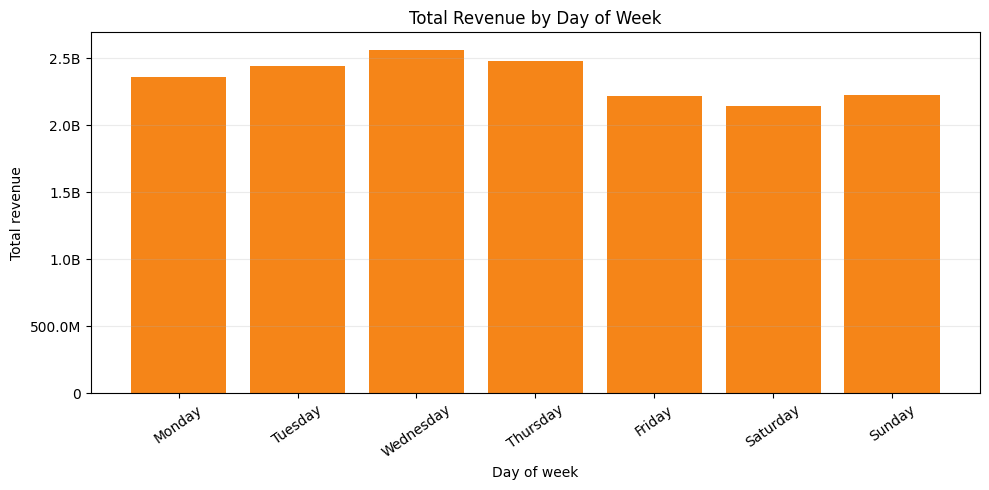

In [5]:
if not analysis_ready:
    print("WARNING: Skipping weekday revenue analysis because usable daily revenue data is not available.")
else:
    weekday_stats = (
        daily.groupby("weekday_name", observed=True)
        .agg(
            total_revenue=("revenue", "sum"),
            average_daily_revenue=("revenue", "mean"),
            median_daily_revenue=("revenue", "median"),
            std_daily_revenue=("revenue", "std"),
            min_daily_revenue=("revenue", "min"),
            max_daily_revenue=("revenue", "max"),
            number_of_days=("revenue", "size"),
        )
        .reindex(WEEKDAY_ORDER)
    )
    weekday_stats["rank_by_average_revenue"] = weekday_stats["average_daily_revenue"].rank(ascending=False, method="min")
    weekday_stats = weekday_stats.reset_index().rename(columns={"weekday_name": "weekday"})

    valid_weekday_stats = weekday_stats.dropna(subset=["average_daily_revenue"])
    if len(valid_weekday_stats):
        best_weekday = valid_weekday_stats.sort_values("average_daily_revenue", ascending=False).iloc[0]["weekday"]
        weakest_weekday = valid_weekday_stats.sort_values("average_daily_revenue", ascending=True).iloc[0]["weekday"]

    display(weekday_stats)
    print(f"Best-selling weekday by average revenue: {best_weekday}")
    print(f"Weakest weekday by average revenue: {weakest_weekday}")

    plot_df = weekday_stats.dropna(subset=["average_daily_revenue"])
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(plot_df["weekday"], plot_df["average_daily_revenue"], color="#4C78A8")
    ax.set_title("Average Revenue by Day of Week")
    ax.set_xlabel("Day of week")
    ax.set_ylabel("Average daily revenue")
    ax.yaxis.set_major_formatter(currency_axis)
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(plot_df["weekday"], plot_df["total_revenue"], color="#F58518")
    ax.set_title("Total Revenue by Day of Week")
    ax.set_xlabel("Day of week")
    ax.set_ylabel("Total revenue")
    ax.yaxis.set_major_formatter(currency_axis)
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

## 6. Weekend versus weekday comparison

Compare observed weekday revenue against observed weekend revenue using mean and median daily revenue. These comparisons describe association only and do not imply causality.

,period,average_revenue,median_revenue,total_revenue,std_revenue,number_of_days
0,Weekday,4.405140e+06,3734562.94,1.206127e+10,2.721643e+06,2738
1,Weekend,3.990141e+06,3501407.51,4.369204e+09,2.340537e+06,1095


,average_revenue_weekdays,average_revenue_weekends,median_revenue_weekdays,median_revenue_weekends,absolute_difference_weekend_minus_weekday,percentage_difference_weekend_vs_weekday,weekend_revenue_appears
0,4.405140e+06,3.990141e+06,3734562.94,3501407.51,-414998.753353,-9.420785,lower


Weekends appear weaker than weekdays by average revenue.


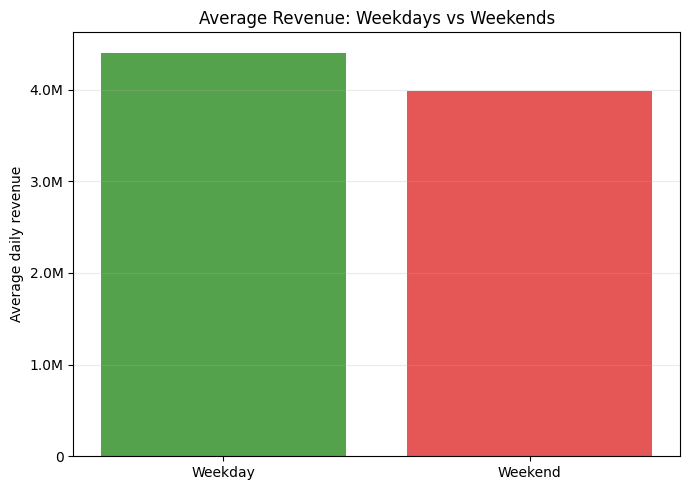

In [6]:
if not analysis_ready:
    print("WARNING: Skipping weekend versus weekday comparison because usable daily revenue data is not available.")
else:
    weekend_summary = (
        daily.groupby("day_type", observed=True)
        .agg(
            average_revenue=("revenue", "mean"),
            median_revenue=("revenue", "median"),
            total_revenue=("revenue", "sum"),
            std_revenue=("revenue", "std"),
            number_of_days=("revenue", "size"),
        )
        .reindex(["Weekday", "Weekend"])
    )

    weekday_avg = weekend_summary.loc["Weekday", "average_revenue"] if "Weekday" in weekend_summary.index else np.nan
    weekend_avg = weekend_summary.loc["Weekend", "average_revenue"] if "Weekend" in weekend_summary.index else np.nan
    weekday_median = weekend_summary.loc["Weekday", "median_revenue"] if "Weekday" in weekend_summary.index else np.nan
    weekend_median = weekend_summary.loc["Weekend", "median_revenue"] if "Weekend" in weekend_summary.index else np.nan
    absolute_difference = weekend_avg - weekday_avg if pd.notna(weekend_avg) and pd.notna(weekday_avg) else np.nan
    percentage_difference = (absolute_difference / weekday_avg * 100) if pd.notna(absolute_difference) and weekday_avg != 0 else np.nan

    if pd.isna(absolute_difference):
        weekend_direction = "not enough data"
        weekend_statement = "Weekend versus weekday comparison could not be evaluated."
    elif pd.notna(percentage_difference) and abs(percentage_difference) <= 5:
        weekend_direction = "similar"
        weekend_statement = "Weekends appear similar to weekdays by average revenue, using a 5 percent practical threshold."
    elif absolute_difference > 0:
        weekend_direction = "higher"
        weekend_statement = "Weekends appear stronger than weekdays by average revenue."
    else:
        weekend_direction = "lower"
        weekend_statement = "Weekends appear weaker than weekdays by average revenue."

    weekend_comparison_df = pd.DataFrame([{
        "average_revenue_weekdays": weekday_avg,
        "average_revenue_weekends": weekend_avg,
        "median_revenue_weekdays": weekday_median,
        "median_revenue_weekends": weekend_median,
        "absolute_difference_weekend_minus_weekday": absolute_difference,
        "percentage_difference_weekend_vs_weekday": percentage_difference,
        "weekend_revenue_appears": weekend_direction,
    }])

    display(weekend_summary.reset_index().rename(columns={"day_type": "period"}))
    display(weekend_comparison_df)
    print(weekend_statement)

    plot_df = weekend_summary.dropna(subset=["average_revenue"]).reset_index()
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.bar(plot_df["day_type"], plot_df["average_revenue"], color=["#54A24B", "#E45756"][:len(plot_df)])
    ax.set_title("Average Revenue: Weekdays vs Weekends")
    ax.set_xlabel("")
    ax.set_ylabel("Average daily revenue")
    ax.yaxis.set_major_formatter(currency_axis)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

## 7. Weekday effect stability across years

Compare average revenue by weekday within each year to see whether the best and weakest weekdays repeat or change over time.

Year x weekday average revenue


weekday_name,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
year,,,,,,,
2012,4.074718e+06,4.544840e+06,4.240528e+06,4.416801e+06,4.112592e+06,3.756547e+06,3.547920e+06
2013,4.511474e+06,4.704142e+06,5.107486e+06,4.939663e+06,4.256947e+06,4.098836e+06,4.159632e+06
2014,5.285695e+06,5.597250e+06,5.645127e+06,5.197266e+06,4.465141e+06,4.600375e+06,5.097622e+06
2015,5.466391e+06,5.462051e+06,5.659398e+06,5.162285e+06,4.677860e+06,4.668739e+06,5.148884e+06
2016,5.584336e+06,5.717395e+06,6.145530e+06,6.559271e+06,5.702525e+06,5.140107e+06,5.416183e+06
2017,5.041301e+06,5.284861e+06,5.696694e+06,5.830461e+06,5.187049e+06,4.842483e+06,4.778418e+06
2018,4.971563e+06,5.661288e+06,5.717385e+06,4.908329e+06,4.734585e+06,4.783947e+06,4.706574e+06
2019,3.333054e+06,3.161542e+06,3.425766e+06,3.077166e+06,2.770684e+06,2.903992e+06,3.128563e+06
2020,3.029706e+06,2.767391e+06,3.047631e+06,2.990108e+06,2.906843e+06,2.597185e+06,2.824105e+06


Yearly best and weakest weekdays


,year,best_weekday,weakest_weekday,best_average_revenue,weakest_average_revenue,weekday_spread_pct,profile_correlation_with_overall,noticeable_pattern_change,change_reason
0,2012,Tuesday,Sunday,4.544840e+06,3.547920e+06,24.320252,0.752627,True,both best and weakest weekdays differ from overall
1,2013,Wednesday,Saturday,5.107486e+06,4.098836e+06,22.218228,0.982065,False,
2,2014,Wednesday,Friday,5.645127e+06,4.465141e+06,23.015479,0.865153,False,
3,2015,Wednesday,Saturday,5.659398e+06,4.668739e+06,19.132278,0.844881,False,
4,2016,Thursday,Saturday,6.559271e+06,5.140107e+06,24.671710,0.807694,False,
5,2017,Thursday,Sunday,5.830461e+06,4.778418e+06,20.087422,0.846138,True,both best and weakest weekdays differ from overall
6,2018,Wednesday,Sunday,5.717385e+06,4.706574e+06,19.940658,0.787048,False,
7,2019,Wednesday,Friday,3.425766e+06,2.770684e+06,21.034007,0.734740,False,
8,2020,Wednesday,Saturday,3.047631e+06,2.597185e+06,15.638185,0.674520,False,
9,2021,Thursday,Saturday,3.342217e+06,2.509121e+06,29.152472,0.826937,True,larger than usual weekday spread


Weekday patterns appear partly stable, with some year-to-year changes.


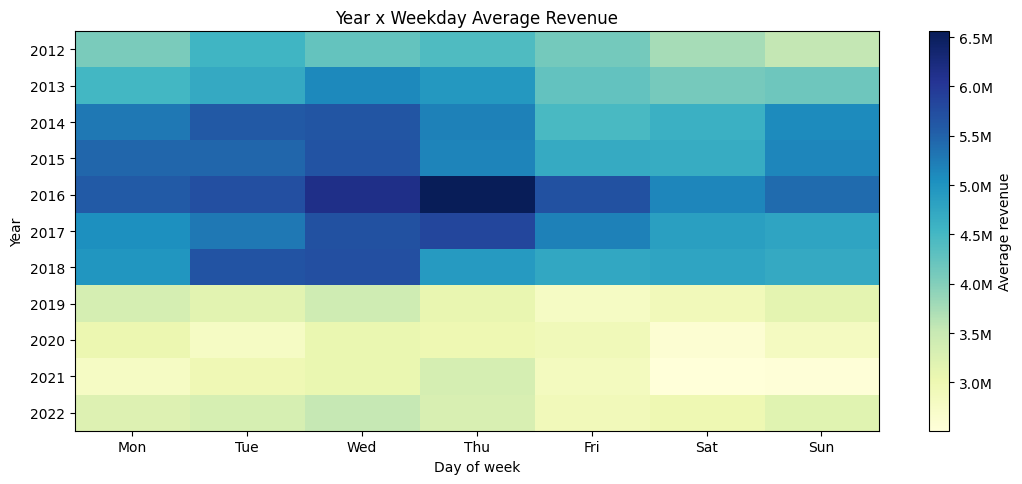

In [7]:
if not analysis_ready:
    print("WARNING: Skipping weekday stability analysis because usable daily revenue data is not available.")
else:
    year_weekday_avg = (
        daily.groupby(["year", "weekday_name"], observed=True)["revenue"]
        .mean()
        .unstack("weekday_name")
        .reindex(columns=WEEKDAY_ORDER)
        .sort_index()
    )

    overall_profile = weekday_stats.set_index("weekday")["average_daily_revenue"].reindex(WEEKDAY_ORDER)
    overall_best = overall_profile.idxmax() if overall_profile.notna().any() else None
    overall_weakest = overall_profile.idxmin() if overall_profile.notna().any() else None
    overall_mean = overall_profile.mean()
    overall_spread_pct = ((overall_profile.max() - overall_profile.min()) / overall_mean * 100) if overall_mean != 0 else np.nan

    pattern_rows = []
    for year, row in year_weekday_avg.iterrows():
        valid = row.dropna()
        if valid.empty:
            continue
        best_for_year = valid.idxmax()
        weakest_for_year = valid.idxmin()
        year_mean = valid.mean()
        spread_pct = ((valid.max() - valid.min()) / year_mean * 100) if year_mean != 0 else np.nan
        corr_valid = row.notna() & overall_profile.notna()
        profile_corr = row[corr_valid].corr(overall_profile[corr_valid]) if int(corr_valid.sum()) >= 3 else np.nan

        reasons = []
        if pd.notna(profile_corr) and profile_corr < 0.50:
            reasons.append("low correlation with overall weekday profile")
        if best_for_year != overall_best and weakest_for_year != overall_weakest:
            reasons.append("both best and weakest weekdays differ from overall")
        if pd.notna(spread_pct) and pd.notna(overall_spread_pct) and spread_pct > max(10, overall_spread_pct * 1.5):
            reasons.append("larger than usual weekday spread")

        pattern_rows.append({
            "year": year,
            "best_weekday": best_for_year,
            "weakest_weekday": weakest_for_year,
            "best_average_revenue": valid.max(),
            "weakest_average_revenue": valid.min(),
            "weekday_spread_pct": spread_pct,
            "profile_correlation_with_overall": profile_corr,
            "noticeable_pattern_change": bool(reasons),
            "change_reason": "; ".join(reasons),
        })

    year_pattern_df = pd.DataFrame(pattern_rows)
    n_years = len(year_pattern_df)
    if n_years >= 2:
        best_consistency = year_pattern_df["best_weekday"].value_counts(normalize=True).max()
        weakest_consistency = year_pattern_df["weakest_weekday"].value_counts(normalize=True).max()
        median_profile_corr = year_pattern_df["profile_correlation_with_overall"].median(skipna=True)
        if best_consistency >= 0.60 and weakest_consistency >= 0.60 and (pd.isna(median_profile_corr) or median_profile_corr >= 0.50):
            stability_statement = "Weekday patterns appear fairly stable across years."
        elif best_consistency >= 0.50 or weakest_consistency >= 0.50 or (pd.notna(median_profile_corr) and median_profile_corr >= 0.30):
            stability_statement = "Weekday patterns appear partly stable, with some year-to-year changes."
        else:
            stability_statement = "Weekday patterns appear to change noticeably across years."
    else:
        stability_statement = "Not enough distinct years to judge weekday pattern stability."

    print("Year x weekday average revenue")
    display(year_weekday_avg)
    print("Yearly best and weakest weekdays")
    display(year_pattern_df)
    print(stability_statement)

    if not year_weekday_avg.empty:
        heatmap_data = np.ma.masked_invalid(year_weekday_avg.to_numpy(dtype=float))
        fig, ax = plt.subplots(figsize=(11, max(4, 0.45 * len(year_weekday_avg))))
        image = ax.imshow(heatmap_data, aspect="auto", cmap="YlGnBu")
        ax.set_title("Year x Weekday Average Revenue")
        ax.set_xlabel("Day of week")
        ax.set_ylabel("Year")
        ax.set_xticks(np.arange(len(WEEKDAY_ORDER)))
        ax.set_xticklabels(WEEKDAY_ABBR)
        ax.set_yticks(np.arange(len(year_weekday_avg.index)))
        ax.set_yticklabels(year_weekday_avg.index.astype(str))
        cbar = fig.colorbar(image, ax=ax)
        cbar.set_label("Average revenue")
        cbar.ax.yaxis.set_major_formatter(currency_axis)
        plt.tight_layout()
        plt.show()

## 8. Distribution and outlier inspection

Use weekday boxplots to inspect distribution shape and identify weekdays with higher volatility. Outlier flags use the standard within-weekday 1.5 x IQR rule.

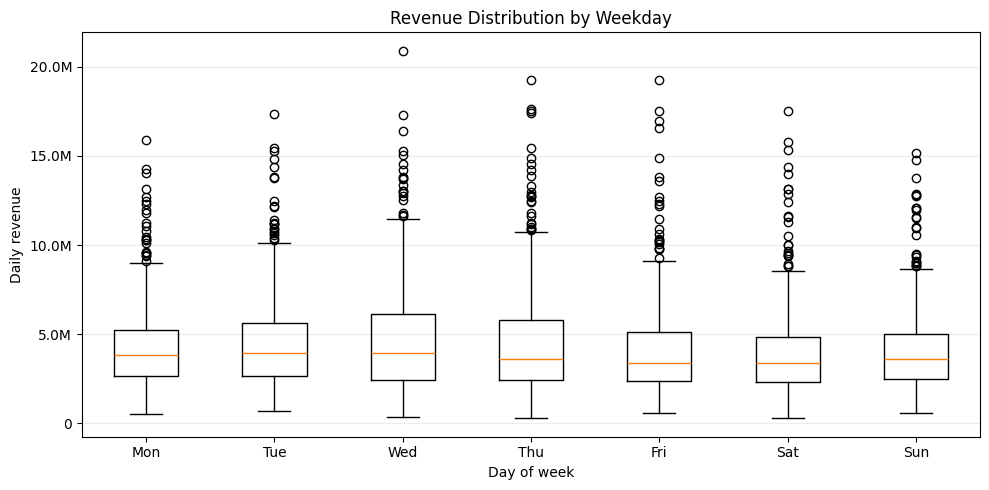

Weekday volatility ranking


,weekday,total_revenue,average_daily_revenue,median_daily_revenue,std_daily_revenue,min_daily_revenue,max_daily_revenue,number_of_days,rank_by_average_revenue,coefficient_of_variation
3,Thursday,2.478628e+09,4.523044e+06,3629496.985,2.971430e+06,306693.87,19289944.12,548,2.0,0.656954
2,Wednesday,2.564676e+09,4.680065e+06,3929024.180,3.007995e+06,370653.23,20905271.35,548,1.0,0.642725
4,Friday,2.217422e+09,4.046390e+06,3359439.985,2.589911e+06,586748.17,19245165.78,548,6.0,0.640055
5,Saturday,2.140806e+09,3.906581e+06,3384605.360,2.407521e+06,279813.94,17529108.34,548,7.0,0.616273
1,Tuesday,2.442411e+09,4.465103e+06,3925730.260,2.606768e+06,679248.37,17347427.27,547,3.0,0.583809
6,Sunday,2.228398e+09,4.073854e+06,3603536.480,2.270571e+06,574193.42,15158669.18,547,5.0,0.557352
0,Monday,2.358136e+09,4.311035e+06,3848593.440,2.339844e+06,545563.72,15902645.06,547,4.0,0.542757


Weekdays with unusually high volatility by top-quartile coefficient of variation: Thursday, Wednesday
Largest within-weekday outlier days


,date,weekday_name,revenue,outlier_type,weekday_median_revenue,absolute_difference_from_weekday_median
0,2018-05-30,Wednesday,20905271.35,unusually_high,3929024.180,1.697625e+07
1,2018-06-01,Friday,19245165.78,unusually_high,3359439.985,1.588573e+07
2,2018-05-31,Thursday,19289944.12,unusually_high,3629496.985,1.566045e+07
3,2017-06-02,Friday,17528852.88,unusually_high,3359439.985,1.416941e+07
4,2018-06-02,Saturday,17529108.34,unusually_high,3384605.360,1.414450e+07
5,2017-06-01,Thursday,17639270.88,unusually_high,3629496.985,1.400977e+07
6,2017-03-30,Thursday,17516038.82,unusually_high,3629496.985,1.388654e+07
7,2016-04-28,Thursday,17388183.19,unusually_high,3629496.985,1.375869e+07
8,2016-04-29,Friday,16966030.50,unusually_high,3359439.985,1.360659e+07
9,2014-04-29,Tuesday,17347427.27,unusually_high,3925730.260,1.342170e+07


In [8]:
if not analysis_ready:
    print("WARNING: Skipping distribution and outlier inspection because usable daily revenue data is not available.")
else:
    boxplot_values = []
    boxplot_labels = []
    for day in WEEKDAY_ORDER:
        values = daily.loc[daily["weekday_name"].astype(str) == day, "revenue"].dropna().values
        if len(values):
            boxplot_values.append(values)
            boxplot_labels.append(day[:3])

    if boxplot_values:
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.boxplot(boxplot_values, tick_labels=boxplot_labels, showfliers=True)
        ax.set_title("Revenue Distribution by Weekday")
        ax.set_xlabel("Day of week")
        ax.set_ylabel("Daily revenue")
        ax.yaxis.set_major_formatter(currency_axis)
        ax.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        plt.show()

    volatility_df = weekday_stats.copy()
    volatility_df["coefficient_of_variation"] = volatility_df["std_daily_revenue"] / volatility_df["average_daily_revenue"].abs()
    volatility_df = volatility_df.sort_values("coefficient_of_variation", ascending=False)
    valid_volatility = volatility_df.dropna(subset=["coefficient_of_variation"])

    if len(valid_volatility):
        threshold = valid_volatility["coefficient_of_variation"].quantile(0.75)
        high_volatility_weekdays = valid_volatility.loc[
            valid_volatility["coefficient_of_variation"] >= threshold, "weekday"
        ].tolist()
    else:
        high_volatility_weekdays = []

    print("Weekday volatility ranking")
    display(volatility_df)
    print("Weekdays with unusually high volatility by top-quartile coefficient of variation:", ", ".join(high_volatility_weekdays) if high_volatility_weekdays else "None flagged")

    outlier_frames = []
    for day, group in daily.groupby("weekday_name", observed=True):
        values = group["revenue"].dropna()
        if len(values) < 4:
            continue
        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0 or pd.isna(iqr):
            continue
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        flagged = group.loc[(group["revenue"] < lower) | (group["revenue"] > upper), ["date", "weekday_name", "revenue"]].copy()
        if flagged.empty:
            continue
        flagged["outlier_type"] = np.where(flagged["revenue"] > upper, "unusually_high", "unusually_low")
        flagged["weekday_median_revenue"] = values.median()
        flagged["absolute_difference_from_weekday_median"] = (flagged["revenue"] - flagged["weekday_median_revenue"]).abs()
        outlier_frames.append(flagged)

    if outlier_frames:
        outlier_days = (
            pd.concat(outlier_frames, ignore_index=True)
            .sort_values("absolute_difference_from_weekday_median", ascending=False)
            .head(20)
            .reset_index(drop=True)
        )
        print("Largest within-weekday outlier days")
        display(outlier_days)
    else:
        outlier_days = pd.DataFrame(columns=["date", "weekday_name", "revenue", "outlier_type"])
        print("No within-weekday outlier days were flagged by the 1.5 x IQR rule.")

## 9. Forecast feature preview

Preview weekday-based forecast features. The cyclical features encode day of week on a circle, which helps models understand that Sunday and Monday are adjacent in the weekly cycle rather than far apart numerically.

In [9]:
if not analysis_ready:
    print("WARNING: Skipping forecast feature preview because usable daily revenue data is not available.")
else:
    feature_preview = daily[[
        "date",
        "revenue",
        "dayofweek",
        "weekday_name",
        "is_weekend",
        "weekday_sin",
        "weekday_cos",
    ]].copy()

    display(feature_preview.head(14))
    print("weekday_sin and weekday_cos preserve repeating weekly seasonality by mapping dayofweek onto a circle instead of a straight 0 to 6 scale.")
    print("Recommended baseline weekday features:", ", ".join(recommended_features))

,date,revenue,dayofweek,weekday_name,is_weekend,weekday_sin,weekday_cos
0,2012-07-04,5123547.94,2,Wednesday,False,0.974928,-0.222521
1,2012-07-05,2751773.45,3,Thursday,False,0.433884,-0.900969
2,2012-07-06,3054029.42,4,Friday,False,-0.433884,-0.900969
3,2012-07-07,2667930.94,5,Saturday,True,-0.974928,-0.222521
4,2012-07-08,2360851.90,6,Sunday,True,-0.781831,0.623490
5,2012-07-09,3548386.46,0,Monday,False,0.000000,1.000000
6,2012-07-10,5234938.62,1,Tuesday,False,0.781831,0.623490
7,2012-07-11,5582884.78,2,Wednesday,False,0.974928,-0.222521
8,2012-07-12,5734632.02,3,Thursday,False,0.433884,-0.900969
9,2012-07-13,5309511.71,4,Friday,False,-0.433884,-0.900969


weekday_sin and weekday_cos preserve repeating weekly seasonality by mapping dayofweek onto a circle instead of a straight 0 to 6 scale.
Recommended baseline weekday features: dayofweek, weekday_name, is_weekend, weekday_sin, weekday_cos


## 10. Key observations and warnings

Summarize the main weekday effects, stability signals, volatility flags, and recommended forecast features. The statements are descriptive and avoid causal claims.

In [10]:
if analysis_ready:
    volatility_text = ", ".join(high_volatility_weekdays) if high_volatility_weekdays else "None flagged"
    if "stronger" in weekend_statement:
        weekend_summary_text = "weekends appear stronger than weekdays"
    elif "weaker" in weekend_statement:
        weekend_summary_text = "weekends appear weaker than weekdays"
    elif "similar" in weekend_statement:
        weekend_summary_text = "weekends appear similar to weekdays"
    else:
        weekend_summary_text = "weekend comparison was not conclusive"

    if not year_pattern_df.empty and "noticeable_pattern_change" in year_pattern_df:
        changed_years = year_pattern_df.loc[year_pattern_df["noticeable_pattern_change"], "year"].astype(str).tolist()
    else:
        changed_years = []

    print("Insight summary")
    print(f"- Best-selling weekday by average daily revenue: {best_weekday}")
    print(f"- Weakest weekday by average daily revenue: {weakest_weekday}")
    print(f"- Weekend versus weekday pattern: {weekend_summary_text}.")
    print(f"- Weekday effect stability: {stability_statement}")
    print(f"- Years flagged for noticeable weekday-pattern changes: {', '.join(changed_years) if changed_years else 'None flagged'}")
    print(f"- Weekdays with unusually high volatility: {volatility_text}")
    print(f"- Recommended forecast features: {', '.join(recommended_features)}")
    if high_volatility_weekdays:
        print("- Consider robust losses or outlier-aware validation for volatile weekdays.")
else:
    print("Insight summary")
    print("- Weekday revenue analysis could not be completed because usable date and revenue columns were not available.")

print("\nWarnings and data notes")
if warning_messages:
    for message in dict.fromkeys(warning_messages):
        print(f"- {message}")
else:
    print("- No critical warnings.")

Insight summary
- Best-selling weekday by average daily revenue: Wednesday
- Weakest weekday by average daily revenue: Saturday
- Weekend versus weekday pattern: weekends appear weaker than weekdays.
- Weekday effect stability: Weekday patterns appear partly stable, with some year-to-year changes.
- Years flagged for noticeable weekday-pattern changes: 2012, 2017, 2021
- Weekdays with unusually high volatility: Thursday, Wednesday
- Recommended forecast features: dayofweek, weekday_name, is_weekend, weekday_sin, weekday_cos
- Consider robust losses or outlier-aware validation for volatile weekdays.

Warnings and data notes
- No critical warnings.
